In [14]:
# Cell 1: Imports and paths
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

RESULTS_DIR = Path("../results/processed")
PLOTS_DIR   = Path("../results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load all four scored result files
t4_df       = pd.read_csv(RESULTS_DIR / "T4_scored.csv")
groq_df     = pd.read_csv(RESULTS_DIR / "Groq_LPU_Llama_scored.csv")
l4_df       = pd.read_csv(RESULTS_DIR / "L4_Llama_scored.csv")
cerebras_df = pd.read_csv(RESULTS_DIR / "Cerebras_WSE_scored.csv")

t4_df["hardware"]       = "T4"
groq_df["hardware"]     = "Groq"
l4_df["hardware"]       = "L4"
cerebras_df["hardware"] = "Cerebras"

combined = pd.concat([t4_df, groq_df, l4_df, cerebras_df], ignore_index=True)

print("T4 rows:",       len(t4_df))
print("Groq rows:",     len(groq_df))
print("L4 rows:",       len(l4_df))
print("Cerebras rows:", len(cerebras_df))
print("Combined:",      len(combined))

T4 rows: 100
Groq rows: 100
L4 rows: 100
Cerebras rows: 100
Combined: 400


In [15]:
# Cell 2: Wilson CI helper
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return 0, 0
    p = successes / n
    center = (p + z**2 / (2*n)) / (1 + z**2 / n)
    margin = (z * ((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)
    return center - margin, center + margin

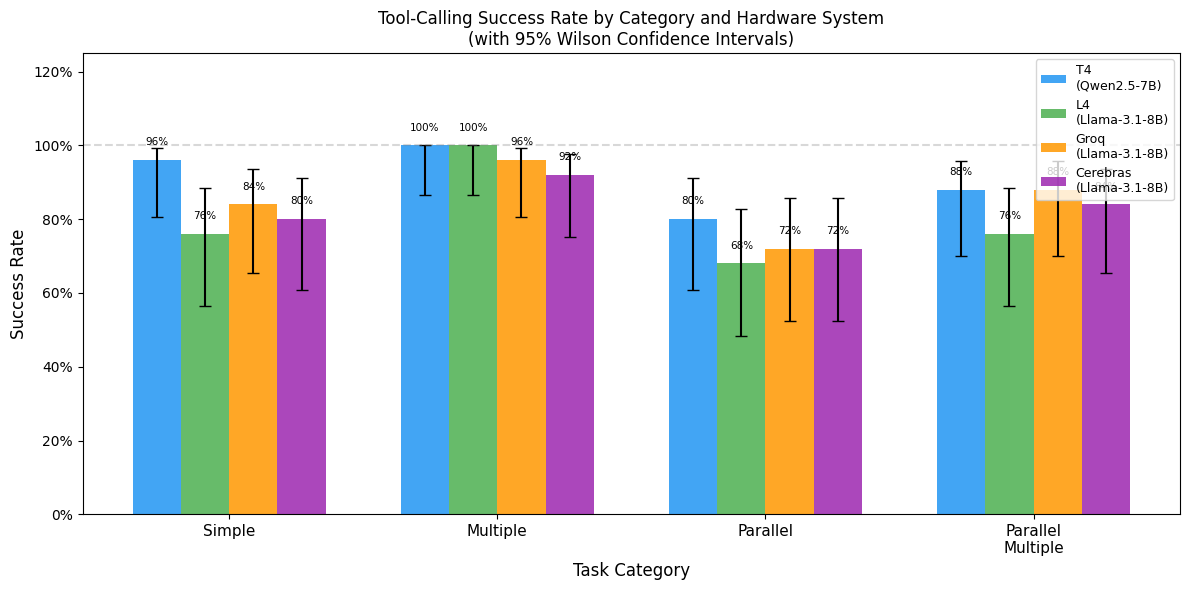

Saved Figure 1


In [16]:
# Cell 3: Figure 1 — four systems correctness
categories = ["simple", "multiple", "parallel", "parallel_multiple"]
cat_labels  = ["Simple", "Multiple", "Parallel", "Parallel\nMultiple"]

systems = {
    "T4\n(Qwen2.5-7B)":        {"df": t4_df,       "color": "#2196F3"},
    "L4\n(Llama-3.1-8B)":      {"df": l4_df,       "color": "#4CAF50"},
    "Groq\n(Llama-3.1-8B)":    {"df": groq_df,     "color": "#FF9800"},
    "Cerebras\n(Llama-3.1-8B)":{"df": cerebras_df, "color": "#9C27B0"},
}

fig, ax = plt.subplots(figsize=(12, 6))
n_systems = len(systems)
width     = 0.18
x         = np.arange(len(categories))

for idx, (label, info) in enumerate(systems.items()):
    df    = info["df"]
    color = info["color"]
    rates, lo_errs, hi_errs = [], [], []

    for cat in categories:
        sub = df[df["category"] == cat]
        n   = len(sub)
        s   = int(sub["correct"].sum())
        r   = s / n
        lo, hi = wilson_ci(s, n)
        rates.append(r)
        lo_errs.append(r - lo)
        hi_errs.append(hi - r)

    offset = (idx - n_systems/2 + 0.5) * width
    bars = ax.bar(x + offset, rates, width,
                  label=label, color=color, alpha=0.85,
                  yerr=[lo_errs, hi_errs], capsize=4,
                  error_kw={"elinewidth": 1.5})

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.04,
                f"{bar.get_height():.0%}",
                ha="center", fontsize=7.5)

ax.set_xlabel("Task Category", fontsize=12)
ax.set_ylabel("Success Rate", fontsize=12)
ax.set_title("Tool-Calling Success Rate by Category and Hardware System\n(with 95% Wilson Confidence Intervals)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_ylim(0, 1.25)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig1_correctness_by_category.pdf", bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig1_correctness_by_category.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 1")

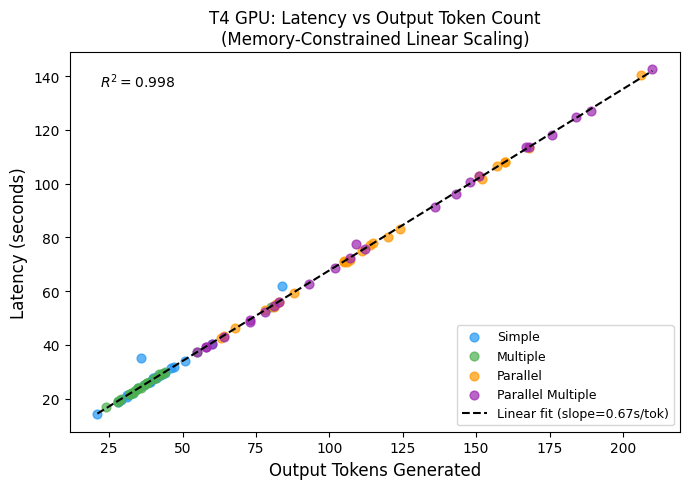

Saved Figure 2 — R²=0.998, slope=0.675s/tok


In [17]:
# Cell 4: Figure 2 — T4 output tokens vs latency scatter with regression
t4_valid = t4_df[t4_df["latency_s"].notna() & t4_df["output_tokens"].notna()].copy()
t4_valid["output_tokens"] = pd.to_numeric(t4_valid["output_tokens"], errors="coerce")
t4_valid["latency_s"]     = pd.to_numeric(t4_valid["latency_s"],     errors="coerce")
t4_valid = t4_valid.dropna(subset=["output_tokens", "latency_s"])

# Color by category
cat_colors = {
    "simple":            "#2196F3",
    "multiple":          "#4CAF50",
    "parallel":          "#FF9800",
    "parallel_multiple": "#9C27B0"
}

fig, ax = plt.subplots(figsize=(7, 5))

for cat, color in cat_colors.items():
    sub = t4_valid[t4_valid["category"] == cat]
    ax.scatter(sub["output_tokens"], sub["latency_s"],
               c=color, alpha=0.7, s=40,
               label=cat.replace("_", " ").title())

# Linear regression
x_vals = t4_valid["output_tokens"].values
y_vals = t4_valid["latency_s"].values
m, b   = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, m * x_line + b,
        color="black", linewidth=1.5, linestyle="--",
        label=f"Linear fit (slope={m:.2f}s/tok)")

r2 = np.corrcoef(x_vals, y_vals)[0, 1]**2
ax.text(0.05, 0.95, f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top")

ax.set_xlabel("Output Tokens Generated", fontsize=12)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_title("T4 GPU: Latency vs Output Token Count\n(Memory-Constrained Linear Scaling)",
             fontsize=12)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig2_t4_tokens_vs_latency.pdf",
            bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig2_t4_tokens_vs_latency.png",
            bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved Figure 2 — R²={r2:.3f}, slope={m:.3f}s/tok")

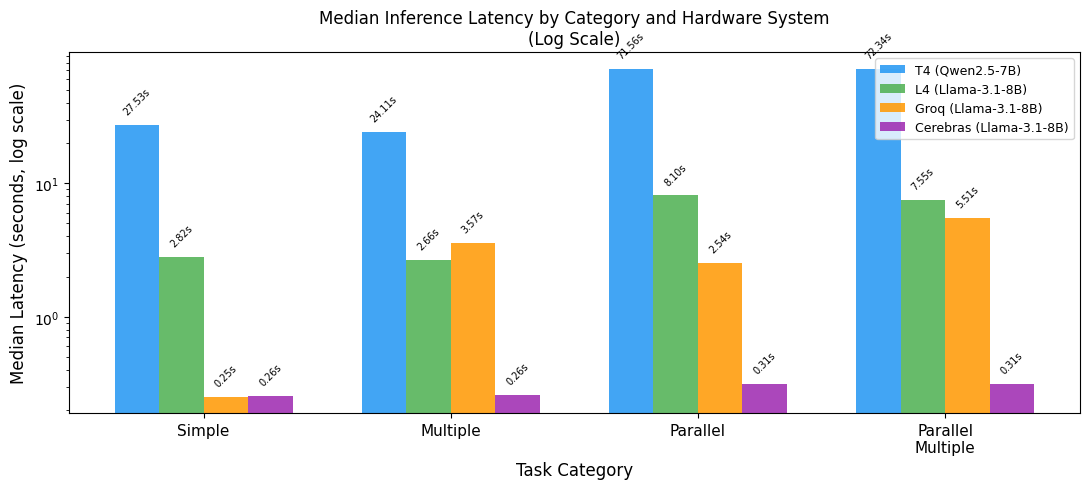

Saved Figure 3


In [18]:
# Cell 5: Figure 3 — Median latency all four systems log scale
cat_order  = ["simple", "multiple", "parallel", "parallel_multiple"]
cat_labels = ["Simple", "Multiple", "Parallel", "Parallel\nMultiple"]

all_systems = {
    "T4 (Qwen2.5-7B)":        {"df": t4_df,       "color": "#2196F3"},
    "L4 (Llama-3.1-8B)":      {"df": l4_df,       "color": "#4CAF50"},
    "Groq (Llama-3.1-8B)":    {"df": groq_df,     "color": "#FF9800"},
    "Cerebras (Llama-3.1-8B)":{"df": cerebras_df, "color": "#9C27B0"},
}

x         = np.arange(len(cat_order))
n_sys     = len(all_systems)
width     = 0.18

fig, ax = plt.subplots(figsize=(11, 5))

for idx, (label, info) in enumerate(all_systems.items()):
    meds   = [info["df"][info["df"]["category"]==c]["latency_s"].median() for c in cat_order]
    offset = (idx - n_sys/2 + 0.5) * width
    bars   = ax.bar(x + offset, meds, width,
                    label=label, color=info["color"], alpha=0.85)
    for bar, val in zip(bars, meds):
        ax.text(bar.get_x() + bar.get_width()/2,
                val * 1.2, f"{val:.2f}s",
                ha="center", fontsize=7, rotation=45)

ax.set_yscale("log")
ax.set_xlabel("Task Category", fontsize=12)
ax.set_ylabel("Median Latency (seconds, log scale)", fontsize=12)
ax.set_title("Median Inference Latency by Category and Hardware System\n(Log Scale)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig3_latency_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig3_latency_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 3")

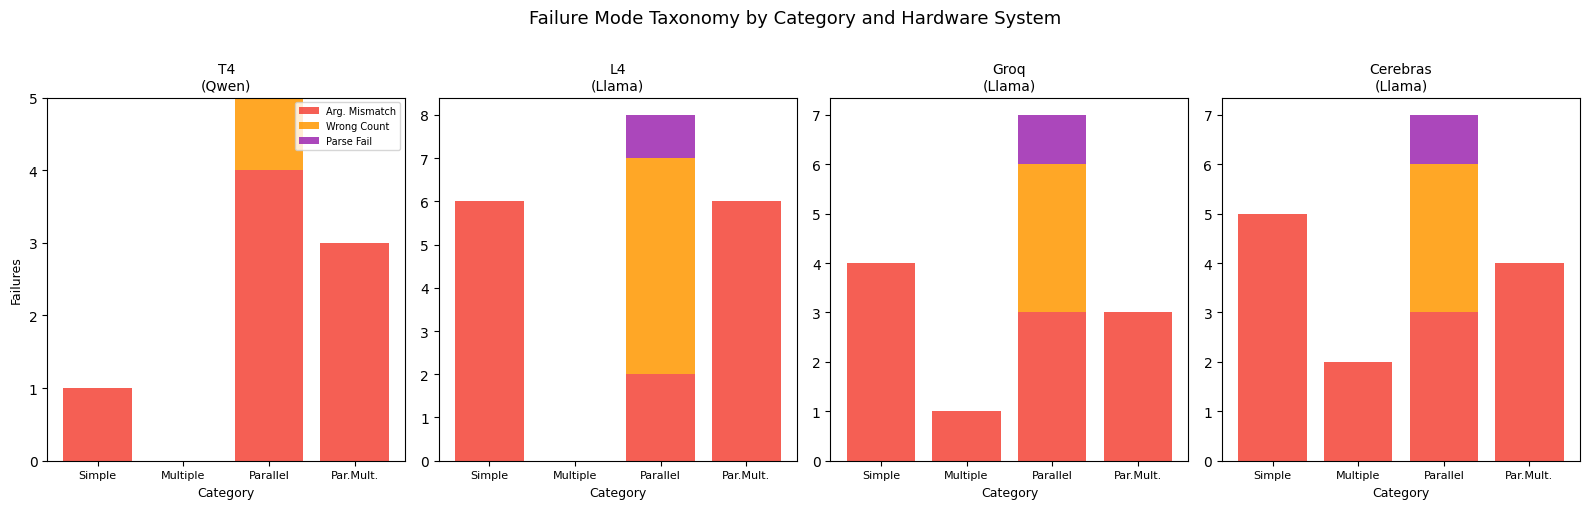

Saved Figure 4


In [19]:
# Cell 6: Figure 4 — Failure taxonomy all four systems
cat_order  = ["simple", "multiple", "parallel", "parallel_multiple"]
cat_labels_short = ["Simple", "Multiple", "Parallel", "Par.Mult."]

failure_types  = ["argument_mismatch", "wrong_call_count", "parse_failure"]
failure_labels = ["Arg. Mismatch", "Wrong Count", "Parse Fail"]
fail_colors    = ["#F44336", "#FF9800", "#9C27B0"]

def get_failure_counts(df, categories):
    counts = {}
    failures = df[df["correct"] == False].copy()
    for cat in categories:
        sub = failures[failures["category"] == cat]
        cat_counts = []
        for ft in failure_types:
            # Match against the prefixed score_reason format
            n = sub["score_reason"].str.contains(
                ft, case=False, na=False
            ).sum()
            cat_counts.append(int(n))
        counts[cat] = cat_counts
    return counts

all_systems_ordered = [
    ("T4\n(Qwen)", t4_df),
    ("L4\n(Llama)", l4_df),
    ("Groq\n(Llama)", groq_df),
    ("Cerebras\n(Llama)", cerebras_df),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, (hw_label, df) in zip(axes, all_systems_ordered):
    failures = get_failure_counts(df, cat_order)
    bottoms  = np.zeros(len(cat_order))

    for j, (ft, color, flabel) in enumerate(zip(failure_types, fail_colors, failure_labels)):
        vals = [failures[c][j] for c in cat_order]
        ax.bar(cat_labels_short, vals, bottom=bottoms,
               color=color, alpha=0.85, label=flabel)
        bottoms += np.array(vals, dtype=float)

    ax.set_title(hw_label, fontsize=10)
    ax.set_xlabel("Category", fontsize=9)
    ax.set_ylabel("Failures" if ax == axes[0] else "", fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.tick_params(axis='x', labelsize=8)
    if ax == axes[0]:
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Failure Mode Taxonomy by Category and Hardware System",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig4_failure_taxonomy.pdf", bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig4_failure_taxonomy.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 4")

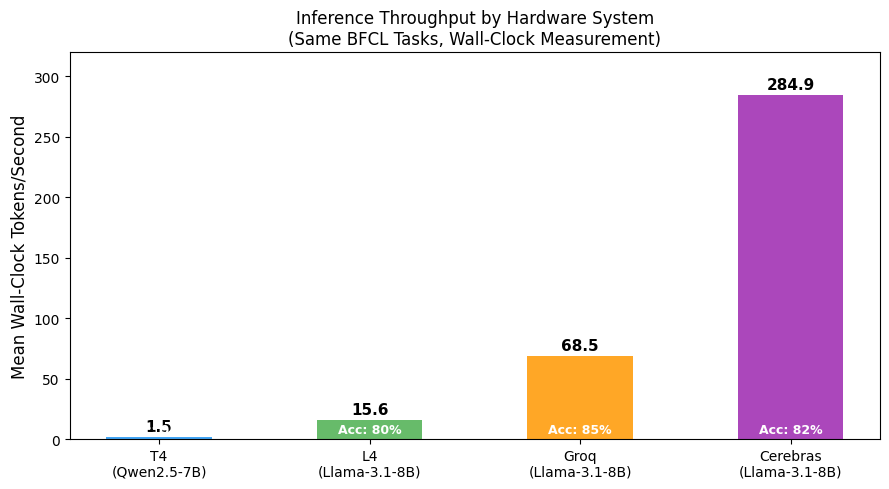

Saved Figure 5


In [20]:
# New Figure 5: Throughput comparison across all four systems
fig, ax = plt.subplots(figsize=(9, 5))

system_names = ["T4\n(Qwen2.5-7B)", "L4\n(Llama-3.1-8B)",
                "Groq\n(Llama-3.1-8B)", "Cerebras\n(Llama-3.1-8B)"]
mean_tps     = [1.47, 15.6, 68.5, 284.9]  # overall mean tok/s
colors       = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

bars = ax.bar(system_names, mean_tps, color=colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, mean_tps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f"{val:.1f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Mean Wall-Clock Tokens/Second", fontsize=12)
ax.set_title("Inference Throughput by Hardware System\n(Same BFCL Tasks, Wall-Clock Measurement)", fontsize=12)
ax.set_ylim(0, 320)

# Add correctness annotation
correctness = ["91%", "80%", "85%", "82%"]
for i, (bar, acc) in enumerate(zip(bars, correctness)):
    ax.text(bar.get_x() + bar.get_width()/2,
            5, f"Acc: {acc}",
            ha="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig5_throughput_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig(PLOTS_DIR / "fig5_throughput_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved Figure 5")

In [21]:
# Cell 7: Print summary stats for paper verification
print("=== T4 SUMMARY ===")
print(t4_df.groupby("category")[["latency_s","output_tokens","tokens_per_second"]].mean().round(2))
print("\n=== GROQ SUMMARY ===")
print(groq_df.groupby("category")[["latency_s","output_tokens","tokens_per_second"]].mean().round(2))
print(f"\nAll plots saved to: {PLOTS_DIR.resolve()}")

=== T4 SUMMARY ===
                   latency_s  output_tokens  tokens_per_second
category                                                      
multiple               25.82          38.00               1.47
parallel               76.93         113.96               1.48
parallel_multiple      77.88         115.12               1.48
simple                 27.98          40.52               1.46

=== GROQ SUMMARY ===
                   latency_s  output_tokens  tokens_per_second
category                                                      
multiple                3.83          42.76              12.23
parallel                2.78         123.24              69.58
parallel_multiple       6.05         122.72              30.03
simple                  0.49          45.00             162.06

All plots saved to: /Users/joe/coding/CSE188/BFCL-hardware-efficiency-study/results/plots
